# Chapter 2: Turning Raw Data into a Forecasting Problem
This notebook walks step-by-step through transforming raw data into a forecasting-ready dataset.

## 1 Setup
We begin by importing essential libraries used for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 2 Creating Raw Data
In real-world scenarios, data is often messy and unordered. Here, we simulate such a dataset by generating random sales data and shuffling it.

In [2]:
dates = pd.date_range(start="2023-01-01", periods=100, freq="D")
sales = np.random.randint(200, 500, size=100)

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

# Shuffle to simulate raw data
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,date,sales
0,2023-01-10,287
1,2023-03-06,407
2,2023-01-07,302
3,2023-02-09,441
4,2023-04-04,415


## 3 Creating Time Index
Time series analysis requires data to be ordered chronologically. We convert the date column into datetime format, sort it, and set it as the index.

In [3]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.set_index("date", inplace=True)
df.head()

,sales
date,
2023-01-01,302
2023-01-02,470
2023-01-03,306
2023-01-04,271
2023-01-05,388


### Visualization
Now that the data is ordered, we can visualize how sales evolve over time.

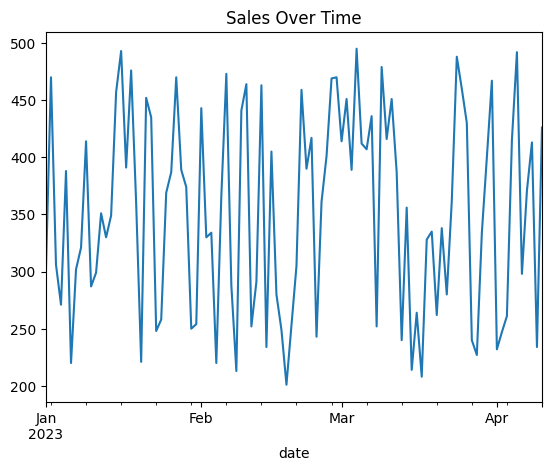

In [4]:
df["sales"].plot(title="Sales Over Time")
plt.show()

## 4 Handling Missing Values
Missing values are common in time series data. We simulate missing values and then apply two common techniques to handle them.

In [5]:
df_missing = df.copy()
df_missing.iloc[10:15] = np.nan
df_missing.iloc[40:42] = np.nan
df_missing.head(20)

,sales
date,
2023-01-01,302.0
2023-01-02,470.0
2023-01-03,306.0
2023-01-04,271.0
2023-01-05,388.0
2023-01-06,220.0
2023-01-07,302.0
2023-01-08,321.0
2023-01-09,414.0


### Forward Fill
This method replaces missing values with the last observed value.

In [6]:
df_missing["sales_ffill"] = df_missing["sales"].fillna(method="ffill")

C:\Users\oadsa\AppData\Local\Temp\ipykernel_8552\2126526800.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_missing["sales_ffill"] = df_missing["sales"].fillna(method="ffill")


In [21]:
df_missing[["sales", "sales_ffill"]].iloc[8:16]

,sales,sales_ffill
date,,
2023-01-09,414.0,414.0
2023-01-10,287.0,287.0
2023-01-11,NaN,287.0
2023-01-12,NaN,287.0
2023-01-13,NaN,287.0
2023-01-14,NaN,287.0
2023-01-15,NaN,287.0
2023-01-16,493.0,493.0


### Interpolation
This method estimates missing values based on surrounding data points.

In [8]:
df_missing["sales_interp"] = df_missing["sales"].interpolate()

In [22]:
df_missing[["sales", "sales_ffill", "sales_interp"]].iloc[8:16]

,sales,sales_ffill,sales_interp
date,,,
2023-01-09,414.0,414.0,414.000000
2023-01-10,287.0,287.0,287.000000
2023-01-11,NaN,287.0,321.333333
2023-01-12,NaN,287.0,355.666667
2023-01-13,NaN,287.0,390.000000
2023-01-14,NaN,287.0,424.333333
2023-01-15,NaN,287.0,458.666667
2023-01-16,493.0,493.0,493.000000


### Comparison
Visual comparison helps understand how each method behaves.

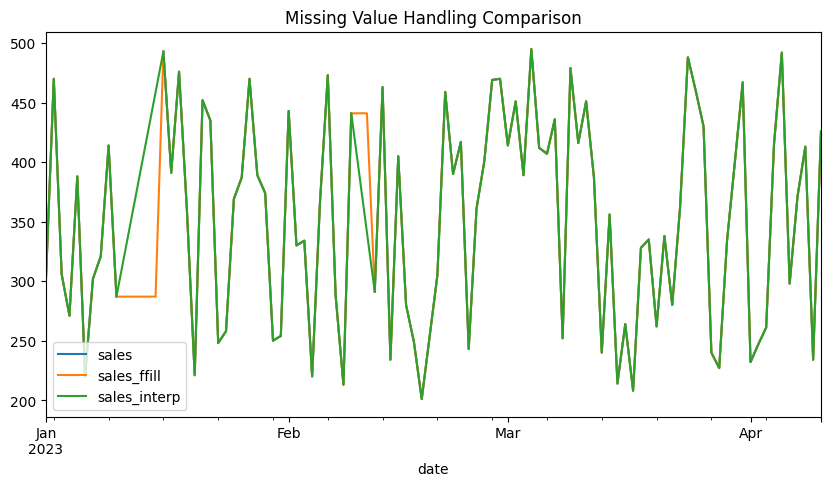

In [9]:
df_missing[["sales", "sales_ffill", "sales_interp"]].plot(figsize=(10,5))
plt.title("Missing Value Handling Comparison")
plt.show()

## 5 Time-Aware Train-Test Split
Unlike traditional ML, time series must preserve order. We split data chronologically to simulate real forecasting.

In [10]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (80, 1)
Test shape: (20, 1)


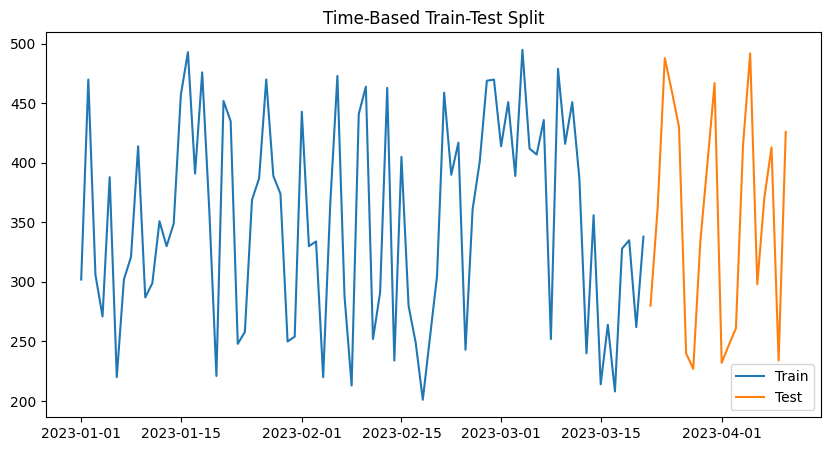

In [11]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train["sales"], label="Train")
plt.plot(test.index, test["sales"], label="Test")
plt.legend()
plt.title("Time-Based Train-Test Split")
plt.show()

## 6. Forecast Horizon
The forecast horizon defines how far into the future we predict.

In [12]:
forecast_horizon = 7
print("Forecast Horizon:", forecast_horizon, "days")

Forecast Horizon: 7 days


## 7 Lag Features
Lag features allow us to use past values as inputs for prediction.

In [13]:
df_lag = df.copy()
df_lag["lag1"] = df_lag["sales"].shift(1)
df_lag["lag2"] = df_lag["sales"].shift(2)
df_lag["lag3"] = df_lag["sales"].shift(3)
df_lag.head()

,sales,lag1,lag2,lag3
date,,,,
2023-01-01,302,NaN,NaN,NaN
2023-01-02,470,302.0,NaN,NaN
2023-01-03,306,470.0,302.0,NaN
2023-01-04,271,306.0,470.0,302.0
2023-01-05,388,271.0,306.0,470.0


Rows with missing lag values are removed before modeling.

In [14]:
df_lag = df_lag.dropna()
df_lag.head()

,sales,lag1,lag2,lag3
date,,,,
2023-01-04,271,306.0,470.0,302.0
2023-01-05,388,271.0,306.0,470.0
2023-01-06,220,388.0,271.0,306.0
2023-01-07,302,220.0,388.0,271.0
2023-01-08,321,302.0,220.0,388.0


## Exercises
Practice these transformations to reinforce learning.

In [15]:
# Exercise 1
data = {"date": ["2024-01-03", "2024-01-01", "2024-01-02"], "sales": [130, 100, 120]}
df_ex1 = pd.DataFrame(data)
df_ex1["date"] = pd.to_datetime(df_ex1["date"])
df_ex1 = df_ex1.sort_values("date")
df_ex1.set_index("date", inplace=True)
df_ex1

,sales
date,
2024-01-01,100
2024-01-02,120
2024-01-03,130


In [16]:
# Exercise 2
data = [100, 120, np.nan, 160]
df_ex2 = pd.DataFrame({"sales": data})
df_ex2["ffill"] = df_ex2["sales"].fillna(method="ffill")
df_ex2["interp"] = df_ex2["sales"].interpolate()
df_ex2

C:\Users\oadsa\AppData\Local\Temp\ipykernel_8552\307367237.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ex2["ffill"] = df_ex2["sales"].fillna(method="ffill")


,sales,ffill,interp
0,100.0,100.0,100.0
1,120.0,120.0,120.0
2,NaN,120.0,140.0
3,160.0,160.0,160.0
